# Exploratory Data Analysis (EDA)

## Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on an e-commerce dataset to understand its structure, identify trends, detect outliers, and generate meaningful business insights using Python.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_excel("Cleaned_Dataset.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (1200, 14)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [5]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [6]:
print("Mean Quantity:", df["Quantity"].mean())
print("Median Quantity:", df["Quantity"].median())
print("Total Orders:", df["OrderID"].count())

print()

print("Mean Total Price:", df["TotalPrice"].mean())
print("Median Total Price:", df["TotalPrice"].median())

Mean Quantity: 2.9458333333333333
Median Quantity: 3.0
Total Orders: 1200

Mean Total Price: 1053.9683
Median Total Price: 823.615


In [7]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

## Distribution of Total Order Price

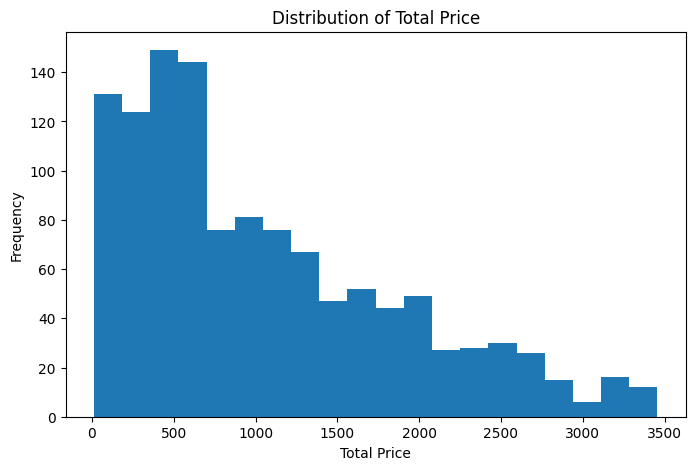

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalPrice"], bins=20)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows the distribution of total order prices. Most orders are concentrated within a lower price range, while fewer orders have higher total prices, indicating a right-skewed distribution. This suggests that high-value orders are less frequent than low- to medium-value orders.

In [5]:
payment = df["PaymentMethod"].value_counts()

payment

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

## Orders by Payment Method


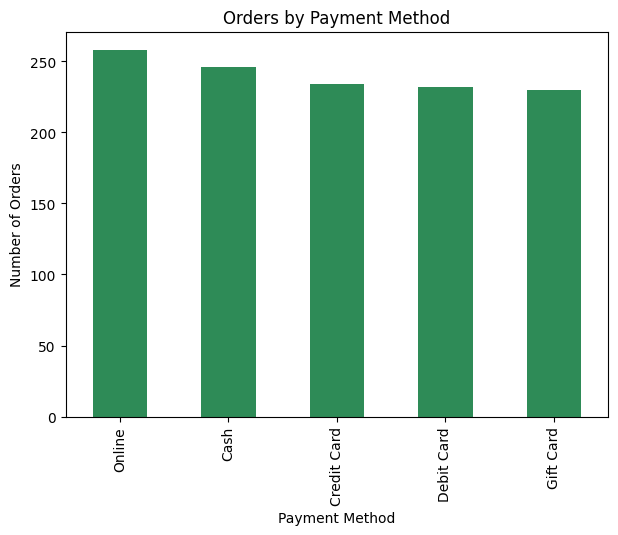

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
payment.plot(kind='bar', color='seagreen')
plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.show()


### Observation

The bar chart shows the distribution of customer orders across different payment methods. One payment method is used more frequently than the others, indicating customer preference for that option. The remaining payment methods are used less often but still contribute to the overall transaction volume.

In [11]:
status = df["OrderStatus"].value_counts()

status

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

## Order Status Distribution



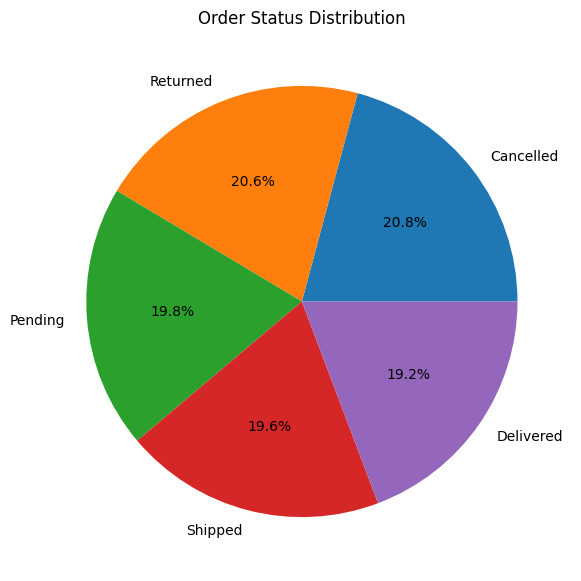

In [12]:
plt.figure(figsize=(7,7))

status.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Order Status Distribution")

plt.show()

### Observation

The order status distribution indicates that most orders belong to a single status category, suggesting efficient order processing. Other status categories occur less frequently, representing orders that are pending, cancelled, or in transit.

In [8]:
referral = df["ReferralSource"].value_counts()

referral

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

## Referral Source Analysis



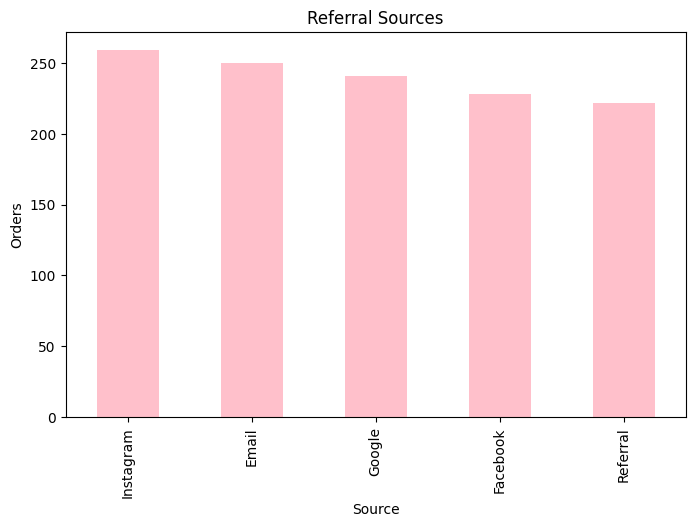

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
referral.plot(kind="bar", color="pink")
plt.title("Referral Sources")
plt.xlabel("Source")
plt.ylabel("Orders")
plt.show()


### Observation

The referral source analysis shows that customers arrive through multiple channels. One referral source contributes the highest number of orders, making it the most effective customer acquisition channel, while the remaining sources contribute comparatively fewer orders.

## Distribution of Total Order Price



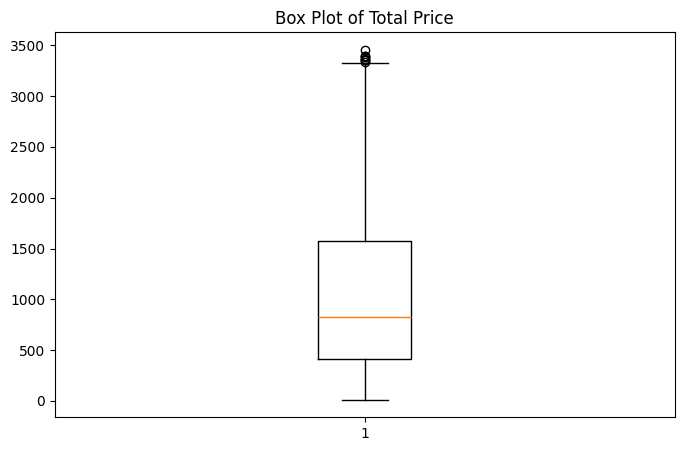

In [15]:
plt.figure(figsize=(8,5))

plt.boxplot(df["TotalPrice"])

plt.title("Box Plot of Total Price")

plt.show()

### Observation

The box plot of **Total Order Price** shows the distribution and spread of order values. Most orders are concentrated within a specific price range, while a few high-value orders appear as outliers beyond the upper whisker. These outliers indicate unusually expensive transactions compared to the majority of orders.

In [16]:
numeric = df.select_dtypes(include="number")

numeric.corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


## Correlation Analysis of Numerical Features



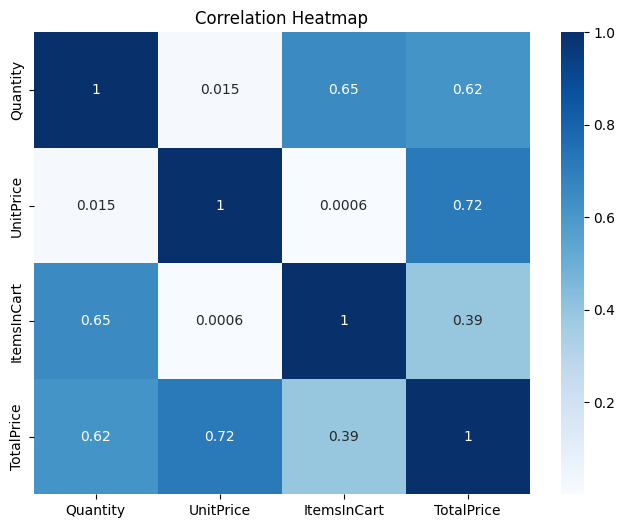

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap illustrates the relationships among the numerical variables in the dataset. A positive correlation is observed between **Quantity** and **Total Price**, indicating that larger order quantities generally result in higher total order values. Other numerical features show varying degrees of correlation, providing insights into how different variables are related.

In [18]:
df.sort_values(by="TotalPrice", ascending=False).head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,No Coupon,Facebook,3390.95
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1031,ORD201031,2023-02-28,C59183,Phone,5,664.51,136 Main St,Debit Card,Pending,TRK18129706,8,SAVE10,Email,3322.55
463,ORD200463,2023-05-26,C25276,Laptop,5,662.78,214 Main St,Debit Card,Shipped,TRK14011732,9,SAVE10,Instagram,3313.90


## Key Observations

- The dataset contains **1200 records** and **14 columns**.
- The average order value is **1053.9683**
- The most preferred payment method is **Credit card**
- The most common order status is **Delivered**
- Outliers are present in the **Total Price** column, indicating a few orders with unusually high values.
- **Quantity** and **Total Price** show a positive relationship, suggesting that larger quantities generally result in higher order values.

## Conclusion

Exploratory Data Analysis was performed to understand the dataset. Basic statistics such as mean, median, and count were calculated. Various charts were used to visualize distributions and identify trends. Outliers were detected using box plots, and correlations between numerical variables were analyzed using a heatmap. The insights obtained from this analysis provide a strong foundation for future predictive modeling and business decision-making.
